## Visualisation Exercise

### Benjamin Bezzina 22/09/2026

In [77]:
import matplotlib.pyplot as plt
from ISLP import load_data

### The Bikeshare Dataset

For this exercise, I am using the Bikeshare dataset from ISLP.

I want to investigate the number of bike rentals across the different months of the year.

The variables I am using are:

- `mnth`: the month of the year. This is categorical data.
- `bikes`: the total number of bike rentals. This is quantitative/numerical data.

My visualisation goal is **Magnitude**, because I want to compare the size of the average number of bike rentals between different months.

According to the Visual Vocabulary guide, appropriate visualisations for magnitude include bar charts and column charts.

In [78]:
data = load_data("Bikeshare")
data.head()

,season,mnth,day,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,bikers
0,1,Jan,1,0,0,6,0,clear,0.24,0.2879,0.81,0.0,3,13,16
1,1,Jan,1,1,0,6,0,clear,0.22,0.2727,0.80,0.0,8,32,40
2,1,Jan,1,2,0,6,0,clear,0.22,0.2727,0.80,0.0,5,27,32
3,1,Jan,1,3,0,6,0,clear,0.24,0.2879,0.75,0.0,3,10,13
4,1,Jan,1,4,0,6,0,clear,0.24,0.2879,0.75,0.0,0,1,1


In [79]:
# Calculate the average number of rentals for each month
monthly_avg = data.groupby("mnth")["bikers"].mean()
monthly_avg = monthly_avg.sort_index()
monthly_avg

/tmp/ipykernel_2322/2442865312.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = data.groupby("mnth")["bikers"].mean()


mnth
Jan       55.507267
Feb       74.291217
March     87.732877
April    131.947149
May      182.555108
June     199.322222
July     189.974462
Aug      186.991792
Sept     177.709902
Oct      166.232840
Nov      142.095967
Dec      117.844804
Name: bikers, dtype: float64

#### Good visualisation: Column chart

The following visualisation uses a column chart to represent magnitude.

This matches the purpose of the analysis because I am comparing the size of the average number of bike rentals across different categories (months).

I consider this a good visualisation because:

- the months are presented in chronological order
- the height of each column represents the magnitude of bike rentals
- the y-axis starts at zero
- the chart has a clear title
- the axes are labelled
- one consistent colour is used because colour does not represent another variable
- the visualisation is simple and makes comparisons between months easy

Starting the y-axis at zero is particularly important for a column chart. The viewer interprets the height of each column as representing the magnitude of the value, so a zero baseline gives a more faithful representation of the differences.

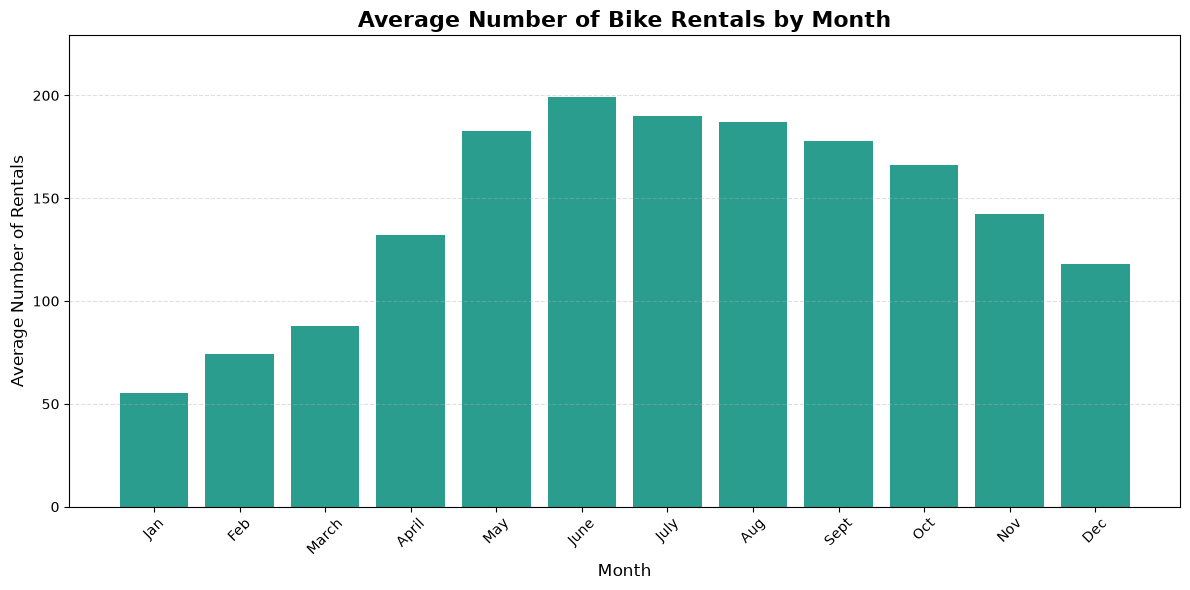

In [80]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_avg.index,
    monthly_avg.values,
    color="#2A9D8F"
)

plt.title(
    "Average Number of Bike Rentals by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Number of Rentals", fontsize=12)
plt.ylim(0, monthly_avg.max() * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Poor visualisation: Pie chart

The following visualisation deliberately uses a pie chart. This is a poor choice for this dataset because the purpose of the visualisation is to compare **magnitude** between months. A pie chart is designed for **Part-to-whole** relationships. It works when the categories represent portions of a meaningful total.

Here, however, the average number of bike rentals in January is not a "part" of the average number of bike rentals in February, and February is not a part of March. The monthly averages are separate values that we want to compare. Therefore, a pie chart makes the relationship between the data and the visualisation less clear.

The column chart is appropriate because we can directly compare the heights of the columns. In the pie chart, we instead have to compare angles or areas of slices, which is less suitable for comparing these magnitudes.

This is an example of a visualisation that does not match the data relationship, rather than simply being an unattractive graph.

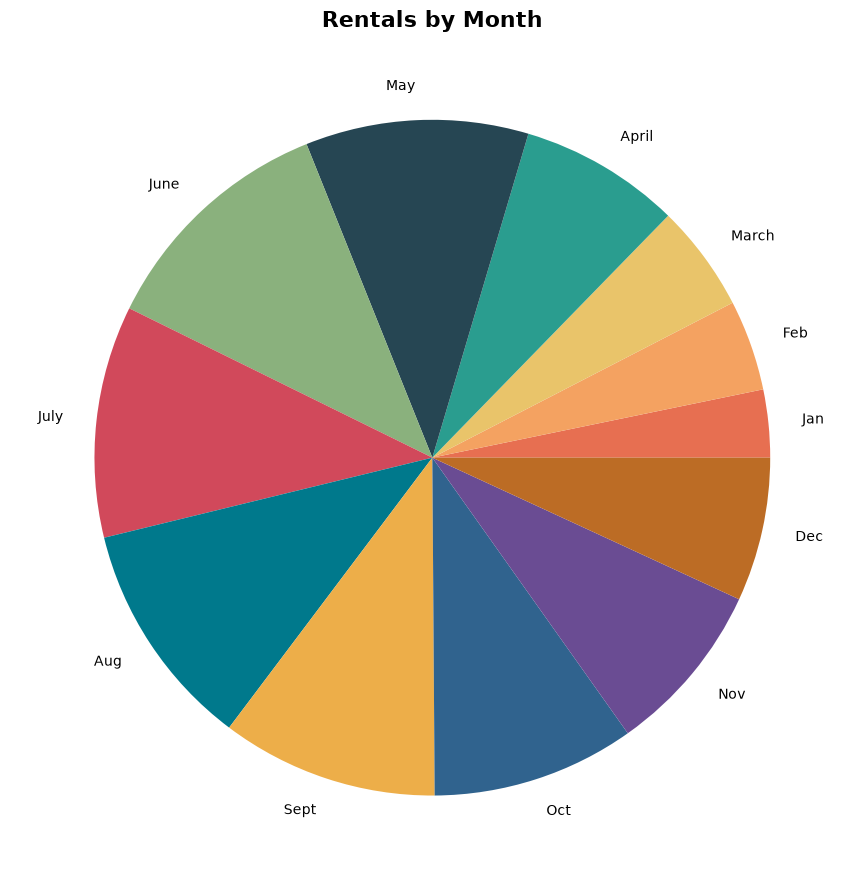

In [84]:
bad_colours = [
    "#E76F51", "#F4A261", "#E9C46A", "#2A9D8F",
    "#264653", "#8AB17D", "#D1495B", "#00798C",
    "#EDAE49", "#30638E", "#6A4C93", "#BC6C25"
]

plt.figure(figsize=(9, 9))

plt.pie(
    monthly_avg.values,
    labels=monthly_avg.index,
    colors=bad_colours,
)

plt.title(
    "Rentals by Month",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()